# Службен весник — translation dataset cleaning

Notebook `01` measured the corpus and wrote `pairs_clean.parquet`: 551,437 rows, 43 columns,
**nothing dropped**. This notebook makes the drops and writes `pairs_filtered.parquet`, the
training-ready subset.

| Filter | Rule |
|---|---|
| OCR | `min(mk_ocr_confidence, sq_ocr_confidence) >= 0.6`, over the sides that were OCR'd. Text-layer rows (no score on either side, ~85%) pass |
| Language | drop confident wrong verdicts only — mk side `ALBANIAN` / `ENGLISH` / undetermined, sq side `MACEDONIAN` / `SERBIAN` / `ENGLISH` / undetermined |
| Alignment | chosen from the sweep in §5 — `ALIGNMENT_MIN_QC` |
| Duplicates | after every other filter, keep the highest-`quality_confidence` copy of each `dup_key` |

| § | |
|---|---|
| 0 | Setup |
| 1 | Load the uploaded `pairs_clean.parquet` |
| 2 | Filter masks |
| 3 | Does the OCR filter catch the language failures? |
| 4 | Waterfall before alignment |
| 5 | Alignment sweep — **the one open decision** |
| 6 | Apply and deduplicate |
| 7 | Write and download |

## Four things worth stating

1. **The lower OCR side, not the average.** `is_high_quality` floors each side separately
   (`>= 0.70`); an average would let a 0.3 side through beside a 0.9 one. The floor here is
   looser, the shape is the same.

2. **"Too short to check" is not "poorly detected".** `01` only ran lingua on texts of at
   least 15 characters, so ~13% of mk sides (`Член 1`, `Прилог:`) were never checked. Those
   rows are kept. `SERBIAN` on the mk side is kept too — it is lingua's standing confusion
   with Macedonian, not a wrong language.

3. **Filter first, deduplicate last.** `01`'s `dup_rank == 1` was picked before any filter.
   Deduplicating first loses a whole group whenever that one copy fails a filter, even when a
   lower copy would have passed.

4. **OCR and language do not check that the two sides translate each other.** A correct
   Macedonian paragraph beside a correct Albanian paragraph about a different act passes both.
   That is what the alignment filter is for, and why §6 refuses to run until it is set.

---
## 0. Setup

Runs on Colab. Upload `pairs_clean.parquet` (from `gs://sl_vesnik_izdanija/DATA_CLEAN/`) when
§1 asks for it, or drop it into `/content` from the file browser first. Outside Colab it reads
`_local/pairs_clean.parquet`, which is where `01`'s `LOCAL_SMOKE_TEST` mode writes it.

Nothing to install — pandas, pyarrow and matplotlib ship with Colab.

In [ ]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

IN_COLAB = "google.colab" in sys.modules

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 160)

print("running in colab:", IN_COLAB, "| pandas", pd.__version__, "| pyarrow", pa.__version__)

running in colab: True | pandas 2.2.3 | pyarrow 23.0.1


### Configuration

`ALIGNMENT_MIN_QC` starts as `None` on purpose. Run §1–§5, read the sweep, set it here, re-run
this cell, then run §6 onward.

In [ ]:
# ---- where the data lives ---------------------------------------------------
DATA_DIR = Path("/content") if IN_COLAB else Path("_local")
INPUT_GLOB = "pairs_clean*.parquet"        # Colab renames a re-upload to "pairs_clean (1).parquet"
OUTPUT_PATH = DATA_DIR / "pairs_filtered.parquet"
EXPECTED_ROWS = 551_437                    # pairs_clean.parquet as 01 §8 wrote it

# ---- OCR ----------------------------------------------------------------------
FILTER_MIN_OCR = 0.60                      # on the lower of the sides that were OCR'd

# ---- language -------------------------------------------------------------------
# keep in step with 01 cell "Independent language check": lingua saw the first
# LINGUA_SNIPPET characters, and only texts at least LINGUA_MIN_CHARS long after stripping
LINGUA_SNIPPET = 300
LINGUA_MIN_CHARS = 15

MK_REJECT = {"ALBANIAN", "ENGLISH"}                 # plus undetermined; SERBIAN is kept
SQ_REJECT = {"MACEDONIAN", "SERBIAN", "ENGLISH"}    # plus undetermined

# ---- alignment: set after reading the sweep in §5 ----------------------------
#   a float            -> keep quality_confidence >= that value
#   "is_high_quality"  -> keep the pipeline's own flag instead
#   None               -> §6 refuses to run
ALIGNMENT_MIN_QC = 0.00
SWEEP_THRESHOLDS = [0.0, 0.3, 0.4, 0.5, 0.55, 0.6, 0.64, 0.7, 0.8]
SAMPLE_BANDS = [(0.3, 0.5), (0.5, 0.64)]

# ---- deduplication --------------------------------------------------------------
# same order as 01 §6: within a dup_key, the highest quality_confidence copy comes first
DEDUPE_SORT = ["dup_key", "quality_confidence", "filename", "slv_identifier"]
DEDUPE_ASCENDING = [True, False, True, True]

SPLITS = ["train", "dev", "test"]

### Chart styling

The same palette as `01`, so a colour means the same thing in both notebooks.

In [ ]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # categorical, fixed order
SEQ_BLUE = "#2a78d6"                                     # magnitude / single-series
SEQ_LIGHT = "#cde2fb"
INK = "#0b0b0b"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"
STATUS = {"good": "#0ca30c", "warning": "#fab219", "critical": "#d03b3b"}

plt.rcParams.update(
    {
        "figure.figsize": (11, 4.2),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "text.color": INK,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "font.size": 10,
    }
)


def thousands(ax, axis="y"):
    '''Format an axis with thousands separators.'''
    fmt = plt.FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax

---
## 1. Load

Looks for `pairs_clean*.parquet` in `DATA_DIR`, newest first. In Colab, if there is none, it
opens the upload dialog; when several parquet files are uploaded at once, the `pairs_clean` one
is used. The column check catches uploading the wrong file (e.g. `pairs_consolidated.parquet`,
which has no forensic columns).

In [ ]:
REQUIRED_COLUMNS = [
    "slv_identifier", "filename", "year", "mk_text", "sq_text",
    "mk_ocr_confidence", "sq_ocr_confidence", "match_confidence", "is_high_quality",
    "quality_confidence", "numeric_overlap_raw", "mk_language", "sq_language",
    "dup_key", "dup_count", "dup_rank", "split", "dup_leaks_into_train",
]


def find_input() -> Path:
    return Path("/content/pairs_clean.parquet")
    '''The pairs_clean parquet to read -- already on disk, or uploaded now.'''
    on_disk = sorted(DATA_DIR.glob(INPUT_GLOB), key=lambda p: p.stat().st_mtime, reverse=True)
    if on_disk:
        return on_disk[0]
    if not IN_COLAB:
        raise FileNotFoundError(f"no {INPUT_GLOB} in {DATA_DIR.resolve()}")

    from google.colab import files

    print(f"no {INPUT_GLOB} in {DATA_DIR} -- upload pairs_clean.parquet")
    uploaded = [name for name in files.upload() if name.endswith(".parquet")]
    chosen = [name for name in uploaded if name.startswith("pairs_clean")] or uploaded
    if len(chosen) != 1:
        raise RuntimeError(f"expected one pairs_clean .parquet upload, got {uploaded}")
    return Path(chosen[0]).resolve()


input_path = find_input()
t0 = time.time()
df = pd.read_parquet("/content/pairs_clean.parquet")
input_columns = list(df.columns)

missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
assert not missing, f"{input_path.name} is missing {missing} -- is this 01's pairs_clean.parquet?"
if len(df) != EXPECTED_ROWS:
    print(f"WARNING: {len(df):,} rows, but 01 wrote {EXPECTED_ROWS:,} -- a subset or a different run")

for column in ("mk_text", "sq_text"):
    df[column] = df[column].fillna("")

print(f"read {input_path} in {time.time() - t0:,.1f}s")
print(f"{len(df):,} rows x {df.shape[1]} columns | "
      f"{int(df['is_high_quality'].sum()):,} is_high_quality | "
      f"{df['filename'].nunique():,} issues")

read /content/pairs_clean.parquet in 5.3s
551,437 rows x 43 columns | 173,133 is_high_quality | 2,674 issues


---
## 2. Filter masks

Three boolean masks, each `True` meaning **drop**. Nothing is removed yet — §3 and §4 need them
side by side.

**A null language is one of two different things.** `01` wrote lingua's verdicts through
`Series.map`, so a text too short to classify (never sent to lingua) and a text lingua looked at
but could not decide on both reached the parquet as null. They are told apart again here with
`01`'s own rule: a text was checked iff its first 300 characters are at least 15 long after
stripping. Only the second kind is a detection failure.

In [ ]:
def lingua_checked(text: pd.Series) -> pd.Series:
    '''True where 01 actually ran lingua on the text.'''
    return text.str.slice(0, LINGUA_SNIPPET).str.strip().str.len() >= LINGUA_MIN_CHARS


# --- OCR: min()/mean() skip nulls, so a text-layer side does not count ----------
ocr_sides = df[["mk_ocr_confidence", "sq_ocr_confidence"]]
ocr_min = ocr_sides.min(axis=1)
ocr_mean = ocr_sides.mean(axis=1)
has_ocr = ocr_min.notna()
ocr_fail = ocr_min < FILTER_MIN_OCR                  # NaN compares False: text layer passes

# --- language ------------------------------------------------------------------
mk_checked = lingua_checked(df["mk_text"])
sq_checked = lingua_checked(df["sq_text"])
mk_undetermined = mk_checked & df["mk_language"].isna()
sq_undetermined = sq_checked & df["sq_language"].isna()

mk_lang_fail = df["mk_language"].isin(MK_REJECT) | mk_undetermined
sq_lang_fail = df["sq_language"].isin(SQ_REJECT) | sq_undetermined
lang_fail = mk_lang_fail | sq_lang_fail

hq = df["is_high_quality"]
mask_rows = {
    f"DROP  OCR lower side < {FILTER_MIN_OCR}": ocr_fail,
    f"        ... of which the average is >= {FILTER_MIN_OCR}": ocr_fail & (ocr_mean >= FILTER_MIN_OCR),
    "DROP  mk side wrong language or undetermined": mk_lang_fail,
    "DROP  sq side wrong language or undetermined": sq_lang_fail,
    "DROP  language, either side": lang_fail,
    "DROP  OCR or language": ocr_fail | lang_fail,
    "keep  mk side never checked (too short)": ~mk_checked,
    "keep  sq side never checked (too short)": ~sq_checked,
    "keep  mk side detected SERBIAN": df["mk_language"].eq("SERBIAN"),
}
mask_table = pd.DataFrame({
    "rows": {label: int(mask.sum()) for label, mask in mask_rows.items()},
    "pct": {label: f"{mask.mean():.2%}" for label, mask in mask_rows.items()},
    "is_high_quality rows": {label: int((mask & hq).sum()) for label, mask in mask_rows.items()},
})
mask_table

,rows,pct,is_high_quality rows
DROP OCR lower side < 0.6,11144,2.02%,0
... of which the average is >= 0.6,3901,0.71%,0
DROP mk side wrong language or undetermined,2681,0.49%,44
DROP sq side wrong language or undetermined,44625,8.09%,1874
"DROP language, either side",46301,8.40%,1899
DROP OCR or language,52625,9.54%,1899
keep mk side never checked (too short),73382,13.31%,31609
keep sq side never checked (too short),75130,13.62%,30466
keep mk side detected SERBIAN,23815,4.32%,4186


In [ ]:
# cross-check against 01's printout: mk side NaN 13.31% (never checked) / None 0.21% (undetermined),
# sq side NaN 13.62% / None 0.24%. Different numbers mean the two notebooks disagree on the rule.
for side, checked, undetermined in (("mk", mk_checked, mk_undetermined), ("sq", sq_checked, sq_undetermined)):
    print(f"{side}: never checked {(~checked).mean():.2%}   undetermined {undetermined.mean():.2%}")

mk: never checked 13.31%   undetermined 0.21%
sq: never checked 13.62%   undetermined 0.24%


---
## 3. Does the OCR filter catch the language failures?

The expectation going in was that dropping low-OCR rows would take most wrong-language pairs with
it. It can only do that for rows that *have* an OCR score, and most rows came from the PDF's text
layer and have none. Measured here rather than assumed.

In [ ]:
n_lang = int(lang_fail.sum())
lang_with_ocr = int((lang_fail & has_ocr).sum())
caught = int((lang_fail & ocr_fail).sum())

print(f"rows with any OCR score           : {int(has_ocr.sum()):>9,}  ({has_ocr.mean():.1%} of rows)")
print(f"language failures                 : {n_lang:>9,}  ({lang_fail.mean():.1%} of rows)")
print(f"  ... that have an OCR score      : {lang_with_ocr:>9,}  ({lang_with_ocr / max(n_lang, 1):.1%})")
print(f"  ... caught by the OCR filter    : {caught:>9,}  ({caught / max(n_lang, 1):.1%})")
print(f"  ... only the language filter gets: {n_lang - caught:>8,}  ({(n_lang - caught) / max(n_lang, 1):.1%})")

pd.crosstab(ocr_fail.rename("ocr_fail"), lang_fail.rename("lang_fail"), margins=True)

rows with any OCR score           :    84,314  (15.3% of rows)
language failures                 :    46,301  (8.4% of rows)
  ... that have an OCR score      :    42,206  (91.2%)
  ... caught by the OCR filter    :     4,820  (10.4%)
  ... only the language filter gets:   41,481  (89.6%)


lang_fail,False,True,All
ocr_fail,,,
False,498812,41481,540293
True,6324,4820,11144
All,505136,46301,551437


In [ ]:
# which verdicts fail, and how much of each the OCR filter would have caught anyway.
# A row can fail on both sides, so the rows column sums to more than the language failures.
reason_masks = {}
for side, reject, undetermined in (("mk", MK_REJECT, mk_undetermined),
                                   ("sq", SQ_REJECT, sq_undetermined)):
    for language in sorted(reject):
        reason_masks[f"{side} = {language}"] = df[f"{side}_language"].eq(language)
    reason_masks[f"{side} undetermined"] = undetermined

reasons = pd.DataFrame({
    "rows": {k: int(m.sum()) for k, m in reason_masks.items()},
    "with an OCR score": {k: int((m & has_ocr).sum()) for k, m in reason_masks.items()},
    "caught by OCR filter": {k: int((m & ocr_fail).sum()) for k, m in reason_masks.items()},
    "is_high_quality": {k: int((m & hq).sum()) for k, m in reason_masks.items()},
})
reasons["pct_caught_by_ocr"] = (
    reasons["caught by OCR filter"] / reasons["rows"].replace(0, np.nan)
).round(3)
reasons.sort_values("rows", ascending=False)

,rows,with an OCR score,caught by OCR filter,is_high_quality,pct_caught_by_ocr
sq = ENGLISH,40519,36866,2217,1747,0.055
sq = MACEDONIAN,1481,1372,384,82,0.259
mk = ALBANIAN,1377,1340,1042,20,0.757
sq = SERBIAN,1321,1297,344,25,0.260
sq undetermined,1304,1136,775,20,0.594
mk undetermined,1174,990,621,15,0.529
mk = ENGLISH,130,112,75,9,0.577


In [ ]:
# language failures the OCR filter lets through -- what the language filter is actually for
PREVIEW_COLUMNS = ["mk_language", "sq_language", "mk_ocr_confidence", "sq_ocr_confidence",
                   "quality_confidence", "is_high_quality", "mk_text", "sq_text"]


def text_preview(frame: pd.DataFrame, n: int, width: int = 90, seed: int = 42) -> pd.DataFrame:
    '''A random sample with texts flattened and cut to `width` characters.'''
    preview = frame.sample(min(len(frame), n), random_state=seed).copy()
    for side in ("mk_text", "sq_text"):
        preview[side] = preview[side].str.replace(r"\s+", " ", regex=True).str.slice(0, width)
    return preview


missed = df[lang_fail & ~ocr_fail]
print(f"{len(missed):,} language failures pass the OCR filter; a sample:")
text_preview(missed, 10)[PREVIEW_COLUMNS].round(3)

41,481 language failures pass the OCR filter; a sample:


,mk_language,sq_language,mk_ocr_confidence,sq_ocr_confidence,quality_confidence,is_high_quality,mk_text,sq_text
12330,MACEDONIAN,ENGLISH,NaN,NaN,0.000,False,ц р Набавувач: Министерство за транспорт и врски ги поканува заинтересираните добавувачи д,sion in Kumanovo and Stip. The Employer The Ministry of Transport and Communications now i
311260,MACEDONIAN,ENGLISH,0.950,0.861,0.000,False,Секоја од Страните номинира девет членови во рок од 30 дена по влегувањето во сила на овој,Each Party shall nominate nine members vrithin thirty (30) days'after the entry into force
190709,MACEDONIAN,ENGLISH,NaN,0.932,0.478,False,ВЛАДА НА РЕПУБЛИКА МАКЕДОНИЈА,"THE COUNCIL OF THE EUROPEAN UNION,"
9732,MACEDONIAN,ENGLISH,NaN,NaN,0.351,False,р) 3.4. Доказ од надлежен орган дека со пресуда не му е изречена мерка на безбедност забра,"b o asto e @ t. et. , o pe so a y, by 03.0 . 003. Commodity Reserves Bureau retains the ri"
3461,MACEDONIAN,ENGLISH,0.726,0.922,0.386,False,ЧЈнстоукции за затворање свињи . Е (дочека се чуваат и за време на процедури),Guidelines for caging non-human primates (in stock and during procedures and breedine)
246272,MACEDONIAN,ENGLISH,0.653,0.916,0.000,False,"Согласно усповите на договорот за градба фидик - црвена книга 1999, член 8.4 - продолжувањ","The Design documentation for construction of Motonvay А2, Kicevo — Ohrid is in discrepancy"
18784,MACEDONIAN,ENGLISH,0.941,0.924,0.348,False,"2. Имајќи ги предвид предлозите на Владиниот комитет согласно член 27, став 4, Комитетот н",2 Having regard to the proposals made by the Governmental Committee pursuant to paragraph
49399,MACEDONIAN,ENGLISH,0.859,0.835,0.000,False,1. Меѓународен договор за одбегнување на двојно оданочување помеѓу 086 (стапка од договоро,ЕУР ЕЕ Full name / Legal person Physical person Data for current address ЕН И Citizenship
344298,MACEDONIAN,ENGLISH,0.941,0.923,0.280,False,"Забелешка: X.A.1.001.j не контролира батерии, вклучително и едноќелијни батерии.","X.A.VII.001 Diesel engines, and tractors and specially designed components therefor, other"
547004,None,None,NaN,0.642,0.000,False,С О Д Р Ж И Н А,“ ni Lë t .


---
## 4. Waterfall before alignment

OCR and language are independent row filters, so their order only changes the per-step counts,
not the result. Deduplication is not independent and always goes last. Alignment is left out
because it is not chosen yet; §6 prints the full waterfall.

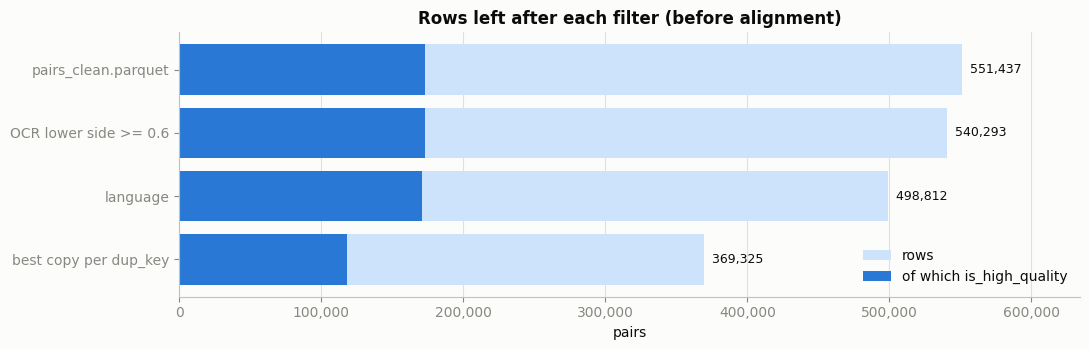

,rows,is_high_quality,removed,pct_of_start,hq_rate
step,,,,,
pairs_clean.parquet,551437,173133,0,1.000,0.314
OCR lower side >= 0.6,540293,173133,11144,0.980,0.320
language,498812,171234,41481,0.905,0.343
best copy per dup_key,369325,117914,129487,0.670,0.319


In [ ]:
def keep_best_copy(frame: pd.DataFrame) -> pd.DataFrame:
    '''One row per dup_key: the highest quality_confidence copy among the rows given.'''
    return (frame.sort_values(DEDUPE_SORT, ascending=DEDUPE_ASCENDING)
                 .drop_duplicates("dup_key", keep="first"))


def waterfall_table(steps: list) -> pd.DataFrame:
    '''steps: (label, frame) in the order they are applied.'''
    table = pd.DataFrame(
        [{"step": label, "rows": len(frame), "is_high_quality": int(frame["is_high_quality"].sum())}
         for label, frame in steps]
    ).set_index("step")
    table["removed"] = (-table["rows"].diff()).fillna(0).astype(int)
    table["pct_of_start"] = (table["rows"] / table["rows"].iloc[0]).round(3)
    table["hq_rate"] = (table["is_high_quality"] / table["rows"].replace(0, np.nan)).round(3)
    return table


def plot_waterfall(table: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(11, 0.55 * len(table) + 1.4))
    labels = list(table.index[::-1])
    rows = table["rows"].to_numpy()[::-1]
    ax.barh(labels, rows, color=SEQ_LIGHT, label="rows")
    ax.barh(labels, table["is_high_quality"].to_numpy()[::-1], color=SEQ_BLUE,
            label="of which is_high_quality")
    for y, value in enumerate(rows):
        ax.text(value, y, f"  {value:,}", va="center", fontsize=9, color=INK)
    ax.set_xlim(0, max(rows.max(), 1) * 1.15)
    ax.set_title(title)
    ax.set_xlabel("pairs")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right")
    thousands(ax, axis="x")
    plt.tight_layout()
    plt.show()


passed = df[~ocr_fail & ~lang_fail]
passed_deduped = keep_best_copy(passed)

pre_alignment = waterfall_table([
    ("pairs_clean.parquet", df),
    (f"OCR lower side >= {FILTER_MIN_OCR}", df[~ocr_fail]),
    ("language", passed),
    ("best copy per dup_key", passed_deduped),
])
plot_waterfall(pre_alignment, "Rows left after each filter (before alignment)")
pre_alignment

---
## 5. Alignment sweep

Each row is a candidate value for `ALIGNMENT_MIN_QC`, applied to the §4 survivors and
deduplicated.

* **`no_shared_numbers`** — share of kept pairs where numerals appear on at least one side and
  none are shared (`numeric_overlap_raw == 0`). Reference numbers and dates survive translation
  verbatim, so this is the most direct sign of a wrong pair available without an encoder. It is
  not proof: a sentence can legitimately spell a number out on one side.
* **`0.64`** is the threshold that best reproduced `is_high_quality` in `01` §5 (97.9%
  agreement); **`0.5`** was `01`'s suggested training cut.
* **`is_high_quality`** — the pipeline's own flag, for comparison. It excludes every
  Gale-Church fallback link.

For a `quality_confidence` threshold, filter-then-deduplicate equals deduplicate-then-filter,
because the kept copy is the highest-scoring one; the sweep uses that shortcut. It does not
hold for `is_high_quality`, so that row deduplicates its own subset.

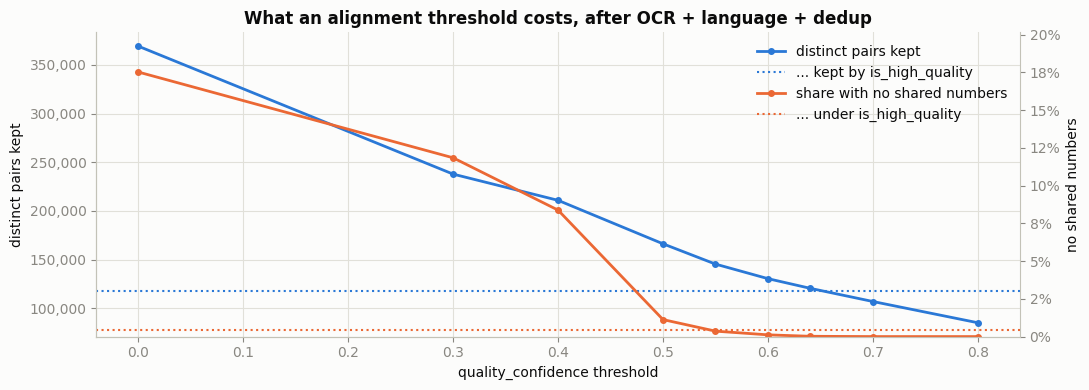

,rows,pct_of_clean,no_shared_numbers,hq_share,mean_match_conf,train,dev,test
alignment,,,,,,,,
qc >= 0.00,369325,0.670,0.175,0.319,0.744,339953,16689,12683
qc >= 0.30,237859,0.431,0.118,0.496,0.888,218574,11108,8177
qc >= 0.40,210920,0.382,0.084,0.559,0.895,193661,9917,7342
qc >= 0.50,166243,0.301,0.011,0.709,0.901,152375,7880,5988
qc >= 0.55,145393,0.264,0.004,0.811,0.904,133086,6952,5355
qc >= 0.60,130441,0.237,0.001,0.901,0.910,119298,6273,4870
qc >= 0.64,120575,0.219,0.000,0.959,0.915,110215,5839,4521
qc >= 0.70,106954,0.194,0.000,1.000,0.923,97780,5190,3984
qc >= 0.80,85133,0.154,0.000,1.000,0.935,77781,4169,3183


In [ ]:
def profile(frame: pd.DataFrame, label: str) -> dict:
    empty = len(frame) == 0
    row = {
        "alignment": label,
        "rows": len(frame),
        "pct_of_clean": len(frame) / len(df),
        "no_shared_numbers": np.nan if empty else float((frame["numeric_overlap_raw"] == 0).mean()),
        "hq_share": np.nan if empty else float(frame["is_high_quality"].mean()),
        "mean_match_conf": np.nan if empty else float(frame["match_confidence"].mean()),
    }
    counts = frame["split"].value_counts()
    row.update({split: int(counts.get(split, 0)) for split in SPLITS})
    return row


sweep = pd.DataFrame(
    [profile(passed_deduped[passed_deduped["quality_confidence"] >= t], f"qc >= {t:.2f}")
     for t in SWEEP_THRESHOLDS]
    + [profile(keep_best_copy(passed[passed["is_high_quality"]]), "is_high_quality")]
).set_index("alignment")

qc_rows = sweep.iloc[:len(SWEEP_THRESHOLDS)]
hq_row = sweep.loc["is_high_quality"]

fig, left = plt.subplots(figsize=(11, 4))
left.plot(SWEEP_THRESHOLDS, qc_rows["rows"], color=SERIES[0], marker="o", markersize=4,
          label="distinct pairs kept")
left.axhline(hq_row["rows"], color=SERIES[0], linestyle=":", linewidth=1.5,
             label="... kept by is_high_quality")
left.set_xlabel("quality_confidence threshold")
left.set_ylabel("distinct pairs kept")
thousands(left)

right = left.twinx()
right.plot(SWEEP_THRESHOLDS, qc_rows["no_shared_numbers"], color=SERIES[1], marker="o",
           markersize=4, label="share with no shared numbers")
right.axhline(hq_row["no_shared_numbers"], color=SERIES[1], linestyle=":", linewidth=1.5,
              label="... under is_high_quality")
right.set_ylabel("no shared numbers")
right.set_ylim(0, max(float(qc_rows["no_shared_numbers"].max()) * 1.15, 0.05))
right.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
right.grid(False)
right.spines["right"].set_visible(True)

handles_l, labels_l = left.get_legend_handles_labels()
handles_r, labels_r = right.get_legend_handles_labels()
left.legend(handles_l + handles_r, labels_l + labels_r, loc="upper right")
left.set_title("What an alignment threshold costs, after OCR + language + dedup")
plt.tight_layout()
plt.show()

sweep.round(3)

In [ ]:
# what the contested bands actually look like -- the rows a lower threshold keeps and a higher one drops
BAND_COLUMNS = ["quality_confidence", "match_confidence", "numeric_overlap_raw",
                "is_high_quality", "mk_text", "sq_text"]

for low, high in SAMPLE_BANDS:
    band = passed_deduped[passed_deduped["quality_confidence"].between(low, high, inclusive="left")]
    print(f"\nquality_confidence in [{low}, {high}): {len(band):,} distinct pairs")
    display(text_preview(band, 5, width=160, seed=7)[BAND_COLUMNS].round(3))


quality_confidence in [0.3, 0.5): 71,616 distinct pairs


,quality_confidence,match_confidence,numeric_overlap_raw,is_high_quality,mk_text,sq_text
528070,0.452,0.808,0.5,False,"р р 15. Доколку најповолниот понудувач ги уплати средствата согласно постигнатата крајна цена од јавното наддавање во утврдениот рок, а врз основа на достав...",ardhshme për pjesën e ndërtimit në fjalë. 15. Nëse ofertuesi më i volitshëm do të paguajë mjetet sipas çmimit përfundimtar të ankandit publik brenda afatit ...
501384,0.409,0.800,NaN,False,д ј Носителот на лиценцата ја врши енергетската дејност производство на електрична енергија од фотонапонска електроцентрала со следните технички карактерист...,"p gj Bartësi i licencës e kryen veprimtarinë energjetike, prodhim të energjisë elektrike nga centrali elektrik diellor, me karakteristikat teknike në vijim:..."
450999,0.442,0.805,NaN,False,"VI Врз основа на наведеното, Судот одлучи како во диспозитивот на оваа одлука.","Kryetari i Kuvendit të Republikës së Maqedonisë së Veriut Afrim Gashi, d.v."
436391,0.364,0.792,NaN,False,"кционирањето на пазарите на енергија, - доставува известувања за сите околности, настани и промени кои што имаат или би можеле да имаат влијание врз вршењет...","Funksionimit të Tregjeve të Energjisë, - të dërgojë njoftime për të gjitha rrethanat, ngjarjet dhe ndryshimet, të cilat kanë apo mund të kenë ndikim në usht..."
282064,0.477,0.828,0.0,False,"Д р ф р ц Носителот на лиценцата е должен во согласност со закон, да обезбеди и да гарантира доверливост на деловните податоци и информации при вршењето на ...","11. Besueshmëria e informatave Bartësi i licensës është i detyruar që në pajtueshmëri me ligjin, të sigurojë besueshmërinë e të dhënave afariste dhe informa..."



quality_confidence in [0.5, 0.64): 45,668 distinct pairs


,quality_confidence,match_confidence,numeric_overlap_raw,is_high_quality,mk_text,sq_text
320813,0.504,0.929,NaN,False,р ц ј - МИПС ‒ обезбедува непречен тек на пораките за пренос на сопственоста на хартии од вредност и овозможува пренос на парични средства; С б б,j - SMPI - siguron rrjedhë të pandërprerë të porosive për kalimin e pronësisë së letrave me vlerë dhe mundëson transferimin e fondeve; Si i i k i i f k i i
539178,0.610,0.831,1.000,False,р д (3) Одобрената финансиска поддршка за реализираните оправдани инвестициски трошоци во претходната година за деловните субјекти од ставовите (1) и (2) на...,(3) Mbështetja financiare e miratuar për kostot e investimit të justifikuara të realizuara në vitin paraprak për subjektet afariste të përmendura në paragra...
200934,0.554,0.832,NaN,False,Агенцијата за вработување доставува месечни извештаи до Управата за јавни приходи за работодавачите кои вработиле странци или каде странците биле ангажирани...,Ne Agjencia për Punësim dorëzon raporte mujore te Drejtoria për të Hyra Publike për punëdhënësit të cilët kanë punësuar të huaj apo ku të huajt kanë qenë të...
353292,0.547,0.833,0.375,False,1. СЕ ДАВА СОГЛАСНОСТ на Одлуката за измена на Статутот на Друштво за управување Генерали Инвестментс АД Скопје донесена од страна на Собранието на акционер...,"1. I JEPET PËLQIM Vendimit për ndryshim të Statutit të Shoqërisë Administruese Generali Investments SHA Shkup, të miratuar nga Kuvendi i aksionarëve më datë..."
158436,0.508,0.932,0.500,False,"р ц ј , што Собранието на Република Македонија го донесе на седницата одржана на 3 октомври 2013 година.","Neni 3 Ky ligj hyn në fuqi në ditën e tetë nga dita e botimit në ""Gazetën Zyrtare të Republikës së Maqedonisë”."


**Set `ALIGNMENT_MIN_QC` in the configuration cell (§0), re-run that cell, then run §6 onward.**

---
## 6. Apply and deduplicate

All four filters, then one copy per `dup_key`. Three columns from `01` describe the corpus
*before* any drop, so they are recomputed for the filtered set:

* **`dup_count`** — copies of the pair **among the rows that passed the filters**. `01`'s
  corpus-wide count is still in `pairs_clean.parquet`.
* **`dup_rank`** — `1` everywhere, by construction.
* **`dup_leaks_into_train`** — recomputed, and `False` everywhere: once each `dup_key` has
  exactly one row, no dev/test text can also sit in train. The cost is that a repeated pair ends
  up in whichever split held its best copy, so split sizes shift a little from `01`'s.

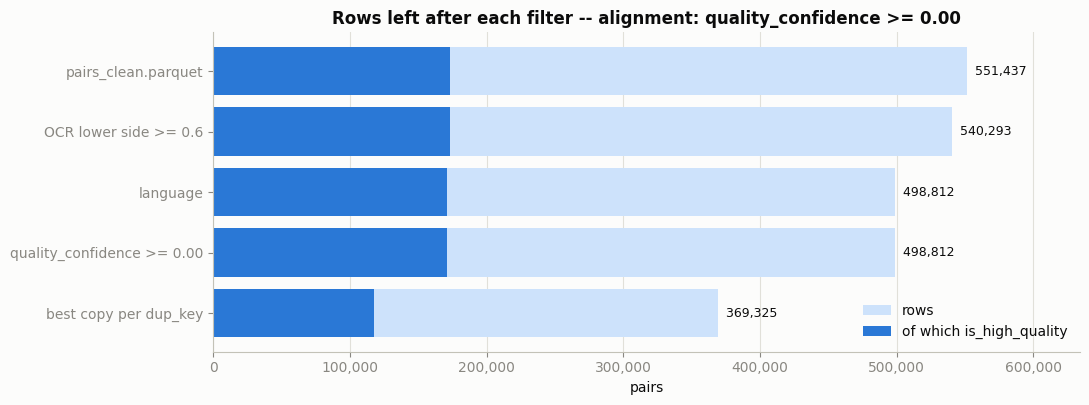

,rows,is_high_quality,removed,pct_of_start,hq_rate
step,,,,,
pairs_clean.parquet,551437,173133,0,1.000,0.314
OCR lower side >= 0.6,540293,173133,11144,0.980,0.320
language,498812,171234,41481,0.905,0.343
quality_confidence >= 0.00,498812,171234,0,0.905,0.343
best copy per dup_key,369325,117914,129487,0.670,0.319


In [ ]:
assert ALIGNMENT_MIN_QC is not None, (
    "ALIGNMENT_MIN_QC is not set -- read the sweep in §5, set it in the configuration cell, "
    "re-run that cell, then run from here"
)

if ALIGNMENT_MIN_QC == "is_high_quality":
    align_fail = ~df["is_high_quality"]
    align_label = "is_high_quality"
else:
    align_threshold = float(ALIGNMENT_MIN_QC)
    align_fail = df["quality_confidence"] < align_threshold
    align_label = f"quality_confidence >= {align_threshold:.2f}"

aligned = df[~ocr_fail & ~lang_fail & ~align_fail]

filtered = keep_best_copy(
    aligned.assign(dup_count=aligned.groupby("dup_key")["dup_key"].transform("size"))
)
filtered["dup_rank"] = 1
train_keys = set(filtered.loc[filtered["split"] == "train", "dup_key"])
filtered["dup_leaks_into_train"] = (filtered["split"] != "train") & filtered["dup_key"].isin(train_keys)
filtered = filtered[input_columns].sort_index()          # 01's row order, 01's column order

# --- invariants ------------------------------------------------------------------
assert filtered["dup_key"].is_unique, "a dup_key survived twice"
assert set(filtered["dup_key"]) == set(aligned["dup_key"]), "a duplicate group vanished in dedup"
assert not filtered["dup_leaks_into_train"].any(), "a dev/test row still shares text with train"
assert not (filtered[["mk_ocr_confidence", "sq_ocr_confidence"]].min(axis=1) < FILTER_MIN_OCR).any()
assert not (lang_fail | align_fail).loc[filtered.index].any(), "a filtered-out row survived"
assert filtered.groupby("filename")["split"].nunique().max() <= 1, "an issue spans two splits"

final_waterfall = waterfall_table([
    ("pairs_clean.parquet", df),
    (f"OCR lower side >= {FILTER_MIN_OCR}", df[~ocr_fail]),
    ("language", df[~ocr_fail & ~lang_fail]),
    (align_label, aligned),
    ("best copy per dup_key", filtered),
])
plot_waterfall(final_waterfall, f"Rows left after each filter -- alignment: {align_label}")
final_waterfall

In [ ]:
split_profile = (
    filtered.groupby("split")
            .agg(issues=("filename", "nunique"),
                 pairs=("split", "size"),
                 high_quality=("is_high_quality", "sum"),
                 mean_quality=("quality_confidence", "mean"))
            .reindex(SPLITS)
            .fillna(0)
            .astype({"issues": int, "pairs": int, "high_quality": int})
)
before = df.groupby("split").size().reindex(SPLITS).fillna(0).astype(int)
split_profile["pairs_in_clean"] = before
split_profile["pct_of_pairs"] = (split_profile["pairs"] / max(len(filtered), 1)).round(3)
split_profile["hq_rate"] = (split_profile["high_quality"] / split_profile["pairs"].replace(0, np.nan)).round(3)
split_profile["mean_quality"] = split_profile["mean_quality"].round(3)
split_profile

,issues,pairs,high_quality,mean_quality,pairs_in_clean,pct_of_pairs,hq_rate
split,,,,,,,
train,2291,339953,107795,0.444,508146,0.920,0.317
dev,97,16689,5688,0.465,24657,0.045,0.341
test,98,12683,4431,0.459,18634,0.034,0.349


---
## 7. Write and download

Same 43 columns in the same order as `pairs_clean.parquet`; only rows are removed, and only the
three duplicate columns above change value. `pairs_clean.parquet` itself is never overwritten.

In [ ]:
pq.write_table(pa.Table.from_pandas(filtered, preserve_index=False), OUTPUT_PATH,
               compression="zstd")

reread = pq.read_table(OUTPUT_PATH)
assert reread.num_rows == len(filtered), "row count changed on the round trip"
assert reread.column_names == input_columns, "column set changed on the round trip"
print(f"wrote {OUTPUT_PATH}  ({OUTPUT_PATH.stat().st_size / 1e6:,.1f} MB)")
print(f"round trip OK: {reread.num_rows:,} rows, {len(reread.column_names)} columns")
del reread

wrote /content/pairs_filtered.parquet  (53.0 MB)
round trip OK: 369,325 rows, 43 columns


In [ ]:
if IN_COLAB:
    from google.colab import files

    files.download(str(OUTPUT_PATH))
    print("download started")
else:
    print("not in Colab -- skipping the browser download")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

download started


In [ ]:
removed = final_waterfall["removed"]
labels = list(final_waterfall.index)

report = f'''
СЛУЖБЕН ВЕСНИК -- mk/sq PARALLEL CORPUS, FILTERED
=======================================================================
rows in {input_path.name:<30}{len(df):>12,}
rows kept                             {len(filtered):>12,}   {len(filtered) / len(df):>6.1%}
  of which is_high_quality            {int(filtered["is_high_quality"].sum()):>12,}   {filtered["is_high_quality"].mean():>6.1%}
  mean quality_confidence             {filtered["quality_confidence"].mean():>12.3f}
issues contributing                   {filtered["filename"].nunique():>12,}
years covered                         {filtered["year"].min()} - {filtered["year"].max()}

REMOVED, IN ORDER
  {labels[1]:<36}{removed.iloc[1]:>12,}
  {labels[2]:<36}{removed.iloc[2]:>12,}
  {labels[3]:<36}{removed.iloc[3]:>12,}
  {labels[4]:<36}{removed.iloc[4]:>12,}

OCR vs LANGUAGE
  language failures caught by OCR     {caught:>12,}   {caught / max(n_lang, 1):>6.1%} of {n_lang:,}

SPLIT (issue-disjoint, deduplicated, no dev/test text in train)
{split_profile[["issues", "pairs", "hq_rate"]].to_string()}

WRITTEN TO
  {OUTPUT_PATH}
=======================================================================
'''
print(report)


СЛУЖБЕН ВЕСНИК -- mk/sq PARALLEL CORPUS, FILTERED
rows in pairs_clean.parquet                551,437
rows kept                                  369,325    67.0%
  of which is_high_quality                 117,914    31.9%
  mean quality_confidence                    0.445
issues contributing                          2,486
years covered                         2001 - 2025

REMOVED, IN ORDER
  OCR lower side >= 0.6                     11,144
  language                                  41,481
  quality_confidence >= 0.00                     0
  best copy per dup_key                    129,487

OCR vs LANGUAGE
  language failures caught by OCR            4,820    10.4% of 46,301

SPLIT (issue-disjoint, deduplicated, no dev/test text in train)
       issues   pairs  hq_rate
split                         
train    2291  339953    0.317
dev        97   16689    0.341
test       98   12683    0.349

WRITTEN TO
  /content/pairs_filtered.parquet



### Reading the output

```python
filtered = pd.read_parquet("pairs_filtered.parquet")

train = filtered[filtered.split == "train"]
dev = filtered[filtered.split == "dev"]
test = filtered[filtered.split == "test"]   # already deduplicated and leak-free
```

Every row passed OCR, language and alignment, and appears once. `is_high_quality` still means
what `dataset.py` says it means; add `& filtered.is_high_quality` for the pipeline's strict subset.

In [ ]:
filtered = pd.read_parquet("pairs_filtered.parquet")

train = filtered[filtered.split == "train"]
dev = filtered[filtered.split == "dev"]
test = filtered[filtered.split == "test"]   #